# 🧹 Data Cleaning

## Objective

The objective of this notebook is to clean the Emergency Response dataset before preprocessing and analysis.

The following data cleaning techniques will be applied:

- Missing value analysis
- Missing value treatment
- Duplicate record detection
- Duplicate removal
- Data type validation
- Text cleaning
- Whitespace removal
- Invalid value detection
- Outlier detection
- Final dataset validation

The cleaned dataset will be stored inside the `data/processed` folder for further preprocessing.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [6]:
df = pd.read_csv("../data/raw/911.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [7]:
clean_df = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


# 📂 Create Working Copy

Instead of modifying the original dataset directly, a duplicate copy is created.

This ensures that the raw dataset always remains unchanged.

# 📏 Dataset Dimensions

Before performing cleaning operations, let's inspect the current dimensions of the dataset.

In [8]:
print("="*50)
print("DATASET SHAPE")
print("="*50)

print(f"Rows    : {clean_df.shape[0]:,}")
print(f"Columns : {clean_df.shape[1]}")

DATASET SHAPE
Rows    : 663,522
Columns : 9


# ❓ Missing Value Analysis

Missing values reduce data quality and may affect analytical results.

We first identify the number and percentage of missing values in every feature.

In [9]:
missing = clean_df.isnull().sum().to_frame("Missing Values")

missing["Percentage (%)"] = (
    missing["Missing Values"] / len(clean_df) * 100
).round(2)

missing

,Missing Values,Percentage (%)
lat,0,0.00
lng,0,0.00
desc,0,0.00
zip,80199,12.09
title,0,0.00
timeStamp,0,0.00
twp,293,0.04
addr,0,0.00
e,0,0.00


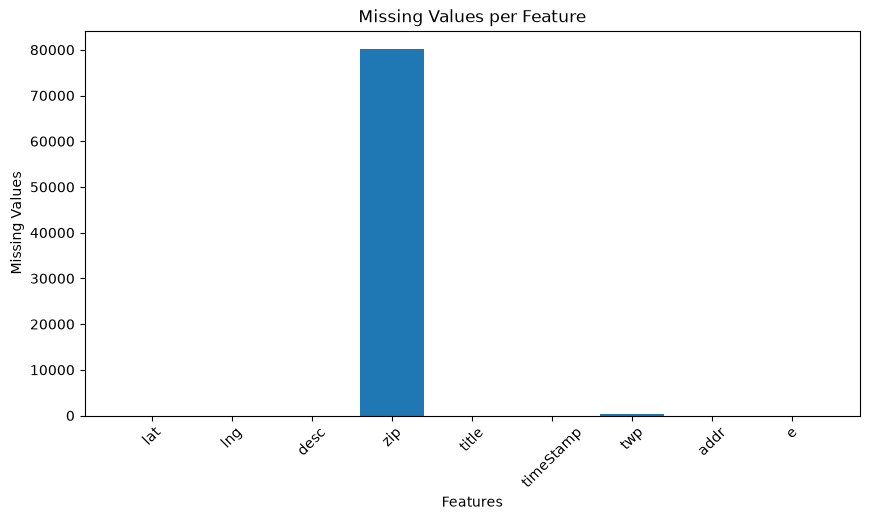

In [10]:
plt.figure(figsize=(10,5))

plt.bar(
    missing.index,
    missing["Missing Values"]
)

plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Missing Values")

plt.xticks(rotation=45)

plt.show()

# 🔍 Missing Value Analysis

This step identifies missing values in each feature before cleaning.

In [16]:
missing_values = df_clean.isnull().sum().to_frame(name="Missing Values")
missing_values["Percentage (%)"] = (
    missing_values["Missing Values"] / len(df_clean) * 100
).round(2)

missing_values

NameError: name 'df_clean' is not defined

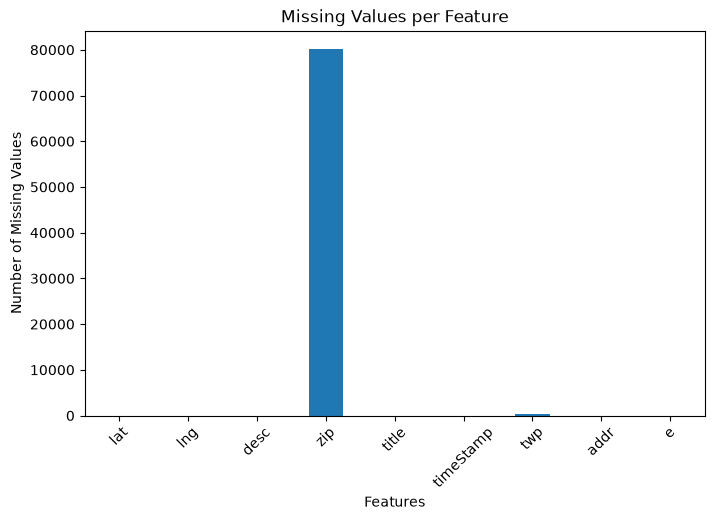

In [12]:
plt.figure(figsize=(8,5))

missing["Missing Values"].plot(kind="bar")

plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

# 📊 Missing Value Visualization

A bar chart helps identify which columns require cleaning.

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

missing_values["Missing Values"].plot(kind="bar")

plt.title("Missing Values per Feature")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.xticks(rotation=45)

plt.show()

NameError: name 'missing_values' is not defined

<Figure size 800x500 with 0 Axes>

# 🧹 Handle Missing Values

Missing ZIP codes are replaced with "Unknown".

Missing townships are replaced with "Unknown".

In [14]:
df_clean["zip"] = df_clean["zip"].fillna("Unknown")
df_clean["twp"] = df_clean["twp"].fillna("Unknown")

print("Missing values handled successfully.")

NameError: name 'df_clean' is not defined

In [13]:
df_clean.isnull().sum()

NameError: name 'df_clean' is not defined

# 🧹 Handle Missing Values

The dataset contains missing values in the `zip` and `twp` columns.

- Missing ZIP codes are replaced with `"Unknown"`.
- Missing townships are replaced with `"Unknown"`.

This preserves all records while removing null values.

In [17]:
clean_df["zip"] = clean_df["zip"].fillna("Unknown")
clean_df["twp"] = clean_df["twp"].fillna("Unknown")

print("✅ Missing values handled successfully.")

✅ Missing values handled successfully.


In [18]:
clean_df.isnull().sum()

lat          0
lng          0
desc         0
zip          0
title        0
timeStamp    0
twp          0
addr         0
e            0
dtype: int64

# 🔍 Duplicate Record Analysis

Duplicate records can negatively impact model performance and statistical analysis.

This section identifies duplicate rows in the dataset before removing them.

In [19]:
duplicate_count = clean_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 240


# 🧹 Remove Duplicate Records

Duplicate records are removed while keeping the first occurrence.

In [20]:
rows_before = len(clean_df)

clean_df = clean_df.drop_duplicates()

rows_after = len(clean_df)

print(f"Rows before cleaning : {rows_before}")
print(f"Rows after cleaning  : {rows_after}")
print(f"Duplicates removed   : {rows_before - rows_after}")

Rows before cleaning : 663522
Rows after cleaning  : 663282
Duplicates removed   : 240


In [21]:
clean_df.duplicated().sum()

np.int64(0)

# 📄 Data Type Validation

Before preprocessing, verify that each column has the appropriate data type.

In [22]:
clean_df.dtypes.to_frame(name="Data Type")

,Data Type
lat,float64
lng,float64
desc,str
zip,object
title,str
timeStamp,str
twp,str
addr,str
e,int64


# 🕒 Convert Timestamp

Convert the `timeStamp` column from string format to datetime for easier feature extraction.

In [23]:
clean_df["timeStamp"] = pd.to_datetime(clean_df["timeStamp"])

print("✅ timeStamp converted successfully.")

✅ timeStamp converted successfully.


In [24]:
clean_df.dtypes

lat                 float64
lng                 float64
desc                    str
zip                  object
title                   str
timeStamp    datetime64[us]
twp                     str
addr                    str
e                     int64
dtype: object

# 📝 Text Cleaning

Convert text columns to a consistent format by removing unnecessary spaces.

In [25]:
text_columns = ["title", "desc", "twp", "addr"]

for col in text_columns:
    clean_df[col] = clean_df[col].astype(str).str.strip()

print("✅ Text cleaned successfully.")

✅ Text cleaned successfully.


In [26]:
clean_df[text_columns].head()

,title,desc,twp,addr
0,EMS: BACK PAINS/INJURY,REINDEER CT & DEAD END; NEW HANOVER; Station ...,NEW HANOVER,REINDEER CT & DEAD END
1,EMS: DIABETIC EMERGENCY,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN
2,Fire: GAS-ODOR/LEAK,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,NORRISTOWN,HAWS AVE
3,EMS: CARDIAC EMERGENCY,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,NORRISTOWN,AIRY ST & SWEDE ST
4,EMS: DIZZINESS,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END


# 🚨 Invalid Value Detection

This section checks for invalid or empty values in important text columns.

In [27]:
text_columns = ["title", "desc", "twp", "addr"]

for col in text_columns:
    invalid = clean_df[col].eq("").sum()
    print(f"{col}: {invalid} empty values")

title: 0 empty values
desc: 0 empty values
twp: 0 empty values
addr: 0 empty values


# 📈 Outlier Detection

Visualize latitude and longitude distributions using boxplots.

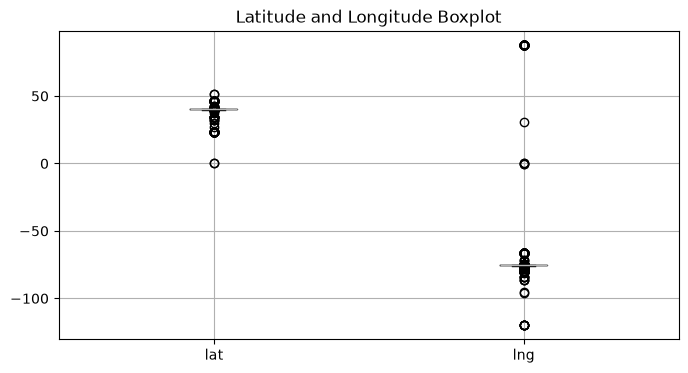

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

clean_df[["lat", "lng"]].boxplot()

plt.title("Latitude and Longitude Boxplot")
plt.show()

# ✅ Final Dataset Validation

Verify that the cleaned dataset contains no missing values or duplicate records.

In [29]:
print("Shape:", clean_df.shape)
print("Missing Values:", clean_df.isnull().sum().sum())
print("Duplicate Rows:", clean_df.duplicated().sum())

Shape: (663282, 9)
Missing Values: 0
Duplicate Rows: 0


# 💾 Save Cleaned Dataset

Store the cleaned dataset for feature engineering and model development.

In [30]:
import os

os.makedirs("../data/processed", exist_ok=True)

clean_df.to_csv("../data/processed/911_cleaned.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [31]:
import os

os.path.exists("../data/processed/911_cleaned.csv")

True